# Experiment: Student Dataset Insight Analysis

## Objective
Extract meaningful, chart-backed insights from the student behavior and performance dataset.

## Success Criteria
- Clean, reproducible loading + profiling.
- Visualize major relationships with `exam_score`.
- Provide concise, data-backed takeaways.


In [1]:
# Setup and data loading
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")

DATA_PATH = Path('/Users/pge7181/Desktop/demo/Kaggle/1/student_dataset.csv')

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Dataset not found at: {DATA_PATH}")

df = pd.read_csv(DATA_PATH)
print(f"Rows: {df.shape[0]:,} | Columns: {df.shape[1]}")
df.head()


Rows: 5,000 | Columns: 21


,student_id,age,gender,academic_level,study_hours,self_study_hours,online_classes_hours,social_media_hours,gaming_hours,sleep_hours,...,exercise_minutes,caffeine_intake_mg,part_time_job,upcoming_deadline,internet_quality,mental_health_score,focus_index,burnout_level,productivity_score,exam_score
0,1,18,Other,High School,7.64,1.56,2.20,3.05,2.19,6.52,...,81,38,1,0,Good,10,43.05,31.77,73.65,50.16
1,2,18,Other,High School,2.21,2.22,2.10,1.65,2.55,5.97,...,111,339,0,0,Good,3,15.92,37.00,13.70,1.00
2,3,22,Male,High School,3.45,0.00,0.29,1.34,2.08,8.39,...,68,266,0,1,Good,8,27.39,34.37,45.15,18.30
3,4,17,Other,High School,5.75,2.08,3.01,2.27,2.20,6.31,...,113,480,1,1,Poor,3,22.31,77.31,20.92,9.37
4,5,19,Other,High School,6.83,1.72,3.33,2.65,0.70,8.01,...,121,24,1,0,Good,8,38.11,39.53,59.23,27.81


## 1) Dataset Profile
Quick checks for data types, missing values, and base statistics.


In [2]:
# Quick profile
display(df.info())

missing = df.isna().sum().sort_values(ascending=False)
print("\nMissing values (non-zero only):")
display(missing[missing > 0])

display(df.describe(include='all').T.head(21))


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   student_id            5000 non-null   int64  
 1   age                   5000 non-null   int64  
 2   gender                5000 non-null   object 
 3   academic_level        5000 non-null   object 
 4   study_hours           5000 non-null   float64
 5   self_study_hours      5000 non-null   float64
 6   online_classes_hours  5000 non-null   float64
 7   social_media_hours    5000 non-null   float64
 8   gaming_hours          5000 non-null   float64
 9   sleep_hours           5000 non-null   float64
 10  screen_time_hours     5000 non-null   float64
 11  exercise_minutes      5000 non-null   int64  
 12  caffeine_intake_mg    5000 non-null   int64  
 13  part_time_job         5000 non-null   int64  
 14  upcoming_deadline     5000 non-null   int64  
 15  internet_quality     

None


Missing values (non-zero only):


Series([], dtype: int64)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
student_id,5000.0,NaN,NaN,NaN,2500.5,1443.520003,1.0,1250.75,2500.5,3750.25,5000.0
age,5000.0,NaN,NaN,NaN,20.5204,2.870406,16.0,18.0,20.0,23.0,25.0
gender,5000,3,Male,1719,NaN,NaN,NaN,NaN,NaN,NaN,NaN
academic_level,5000,3,Postgraduate,1687,NaN,NaN,NaN,NaN,NaN,NaN,NaN
study_hours,5000.0,NaN,NaN,NaN,4.539594,1.821665,0.0,3.25,4.53,5.76,11.84
self_study_hours,5000.0,NaN,NaN,NaN,2.478734,1.17799,0.0,1.66,2.48,3.29,7.41
online_classes_hours,5000.0,NaN,NaN,NaN,2.011984,0.983906,0.0,1.32,2.01,2.69,6.0
social_media_hours,5000.0,NaN,NaN,NaN,2.998086,1.467949,0.0,1.99,2.98,4.03,8.28
gaming_hours,5000.0,NaN,NaN,NaN,1.564514,1.110807,0.0,0.67,1.49,2.34,5.64
sleep_hours,5000.0,NaN,NaN,NaN,7.016492,1.163692,4.0,6.2375,7.01,7.81,10.0


## 2) Feature Engineering
Create interpretable bins/flags for easier comparison across student groups.


In [3]:
# Engineered fields used in charts and grouped summaries
df['has_part_time_job'] = df['part_time_job'].map({0: 'No', 1: 'Yes'})
df['deadline_soon'] = df['upcoming_deadline'].map({0: 'No', 1: 'Yes'})

sleep_bins = [0, 5, 6, 7, 8, 9, 24]
sleep_labels = ['<5h', '5-6h', '6-7h', '7-8h', '8-9h', '9h+']
df['sleep_bin'] = pd.cut(df['sleep_hours'], bins=sleep_bins, labels=sleep_labels, right=False)

burnout_q = pd.qcut(df['burnout_level'], 4, labels=['Q1 (lowest)', 'Q2', 'Q3', 'Q4 (highest)'])
df['burnout_quartile'] = burnout_q

df[['sleep_hours', 'sleep_bin', 'burnout_level', 'burnout_quartile']].head()


,sleep_hours,sleep_bin,burnout_level,burnout_quartile
0,6.52,6-7h,31.77,Q1 (lowest)
1,5.97,5-6h,37.00,Q2
2,8.39,8-9h,34.37,Q1 (lowest)
3,6.31,6-7h,77.31,Q4 (highest)
4,8.01,8-9h,39.53,Q2


## 3) Core Charts
These plots focus on factors most connected to exam outcomes.


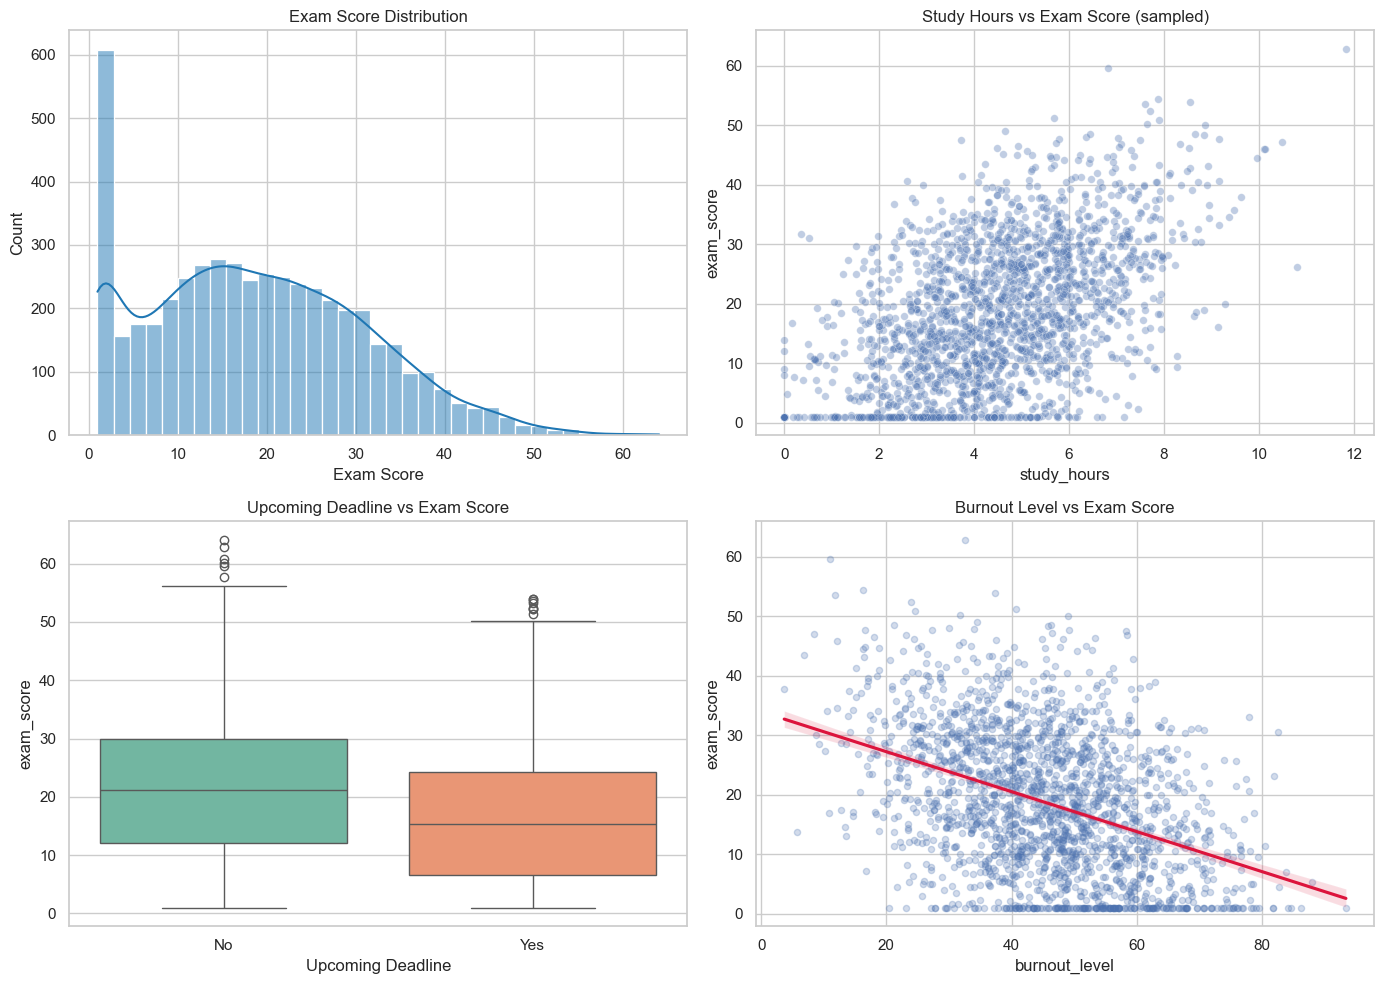

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# A) Distribution of exam scores
sns.histplot(df['exam_score'], bins=35, kde=True, color='#1f77b4', ax=axes[0, 0])
axes[0, 0].set_title('Exam Score Distribution')
axes[0, 0].set_xlabel('Exam Score')

# B) Study hours vs exam score
sample_df = df.sample(min(len(df), 2000), random_state=42)
sns.scatterplot(data=sample_df, x='study_hours', y='exam_score', alpha=0.35, s=30, ax=axes[0, 1])
axes[0, 1].set_title('Study Hours vs Exam Score (sampled)')

# C) Deadline impact
sns.boxplot(data=df, x='deadline_soon', y='exam_score', ax=axes[1, 0], palette='Set2')
axes[1, 0].set_title('Upcoming Deadline vs Exam Score')
axes[1, 0].set_xlabel('Upcoming Deadline')

# D) Burnout vs exam score
sns.regplot(data=sample_df, x='burnout_level', y='exam_score',
            scatter_kws={'alpha':0.25, 's':20}, line_kws={'color':'crimson'}, ax=axes[1, 1])
axes[1, 1].set_title('Burnout Level vs Exam Score')

plt.tight_layout()
plt.show()


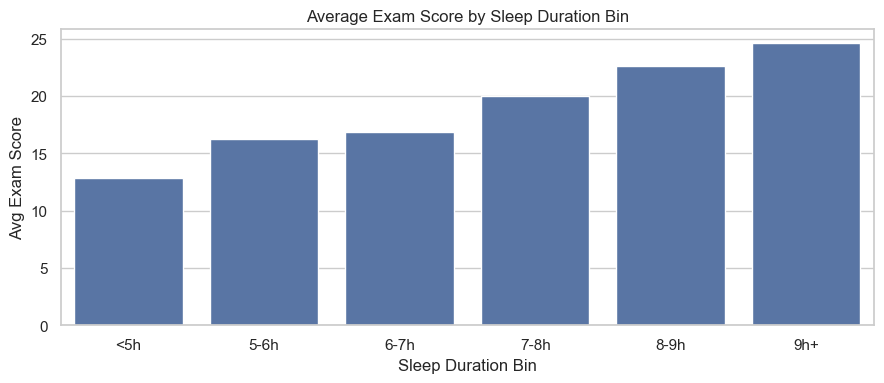

,sleep_bin,exam_score
0,<5h,12.853861
1,5-6h,16.250937
2,6-7h,16.851084
3,7-8h,19.998835
4,8-9h,22.572165
5,9h+,24.575708


In [5]:
# Sleep pattern effect
sleep_summary = df.groupby('sleep_bin', observed=False)['exam_score'].mean().reset_index()

plt.figure(figsize=(9, 4))
sns.barplot(data=sleep_summary, x='sleep_bin', y='exam_score', color='#4c72b0')
plt.title('Average Exam Score by Sleep Duration Bin')
plt.xlabel('Sleep Duration Bin')
plt.ylabel('Avg Exam Score')
plt.tight_layout()
plt.show()

sleep_summary


## 4) Correlation Heatmap
Use numeric correlations to identify strongest linear relationships with `exam_score`.


,corr_with_exam_score
exam_score,1.000000
productivity_score,0.886401
focus_index,0.749879
mental_health_score,0.546547
study_hours,0.513434
sleep_hours,0.234710
self_study_hours,0.083602
exercise_minutes,0.040724
online_classes_hours,0.004975
age,-0.009047


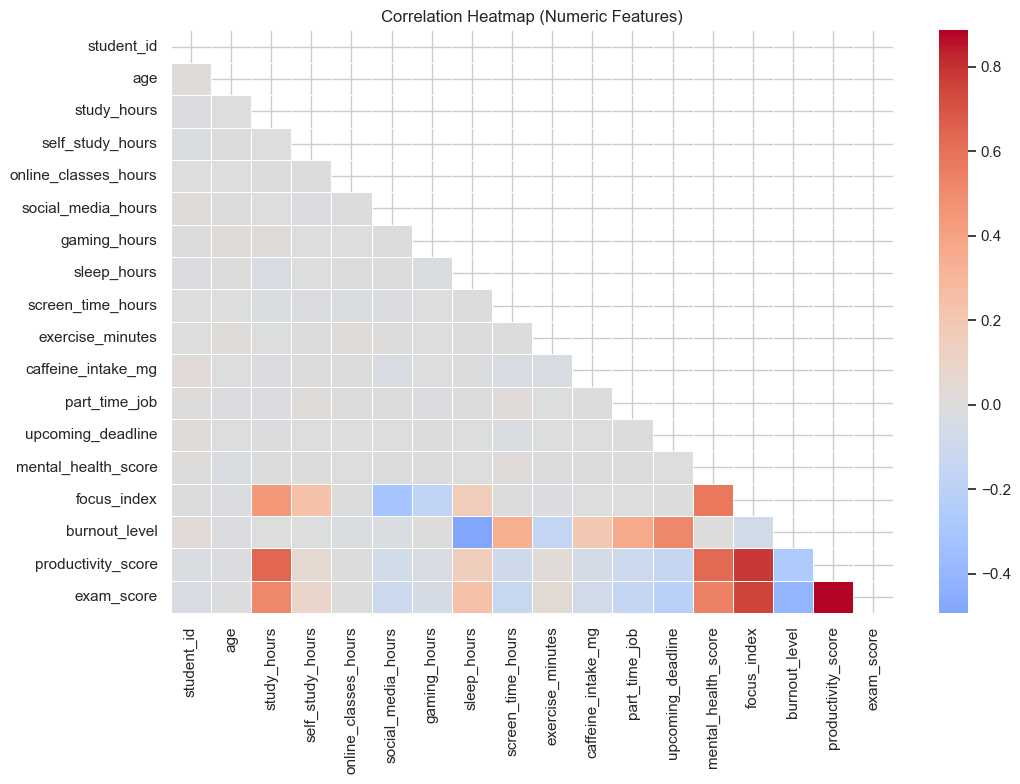

In [6]:
numeric_cols = [c for c in df.columns if df[c].dtype != 'object']
corr = df[numeric_cols].corr(numeric_only=True)

target_corr = corr['exam_score'].sort_values(ascending=False)
display(target_corr.to_frame('corr_with_exam_score'))

plt.figure(figsize=(11, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='coolwarm', center=0, linewidths=0.4)
plt.title('Correlation Heatmap (Numeric Features)')
plt.tight_layout()
plt.show()


## 5) Grouped Comparisons
Compare performance across key categorical attributes.


In [7]:
group_cols = ['academic_level', 'gender', 'internet_quality', 'has_part_time_job', 'deadline_soon']
for col in group_cols:
    summary = (
        df.groupby(col, observed=False)['exam_score']
        .agg(['count', 'mean', 'median'])
        .sort_values('mean', ascending=False)
        .round(2)
    )
    print(f"\n=== {col} ===")
    display(summary)



=== academic_level ===


,count,mean,median
academic_level,,,
Undergraduate,1641,18.95,18.41
High School,1672,18.81,17.88
Postgraduate,1687,18.65,17.90



=== gender ===


,count,mean,median
gender,,,
Female,1630,19.02,18.55
Male,1719,18.92,17.82
Other,1651,18.47,17.84



=== internet_quality ===


,count,mean,median
internet_quality,,,
Poor,1640,19.01,18.30
Average,1638,18.92,18.21
Good,1722,18.50,17.49



=== has_part_time_job ===


,count,mean,median
has_part_time_job,,,
No,2509,20.61,20.11
Yes,2491,16.98,15.91



=== deadline_soon ===


,count,mean,median
deadline_soon,,,
No,2493,21.42,21.21
Yes,2507,16.20,15.40


## 6) Concise Takeaways
Auto-generated bullet points from the computed results.


In [8]:
corr_with_exam = corr['exam_score'].drop('exam_score').sort_values(ascending=False)

top_pos = corr_with_exam.head(3)
top_neg = corr_with_exam.sort_values().head(3)

deadline_means = df.groupby('deadline_soon', observed=False)['exam_score'].mean()
job_means = df.groupby('has_part_time_job', observed=False)['exam_score'].mean()
burnout_means = df.groupby('burnout_quartile', observed=False)['exam_score'].mean()

print("Key insights:")
print(f"- Strongest positive relationships with exam score: {', '.join([f'{k} ({v:.2f})' for k, v in top_pos.items()])}")
print(f"- Strongest negative relationships: {', '.join([f'{k} ({v:.2f})' for k, v in top_neg.items()])}")
print(f"- Deadline pressure effect: No-deadline avg = {deadline_means['No']:.2f}, Deadline avg = {deadline_means['Yes']:.2f}")
print(f"- Part-time job effect: No-job avg = {job_means['No']:.2f}, Job avg = {job_means['Yes']:.2f}")
print(f"- Burnout gradient: lowest quartile = {burnout_means['Q1 (lowest)']:.2f}, highest quartile = {burnout_means['Q4 (highest)']:.2f}")


Key insights:
- Strongest positive relationships with exam score: productivity_score (0.89), focus_index (0.75), mental_health_score (0.55)
- Strongest negative relationships: burnout_level (-0.41), upcoming_deadline (-0.22), part_time_job (-0.15)
- Deadline pressure effect: No-deadline avg = 21.42, Deadline avg = 16.20
- Part-time job effect: No-job avg = 20.61, Job avg = 16.98
- Burnout gradient: lowest quartile = 25.37, highest quartile = 12.57


## 7) Baseline Predictive Model (`exam_score`)
Simple linear regression baseline using a train/test split and one-hot encoded categorical features.


In [10]:
# Baseline linear regression with NumPy (no external ML package required)
import numpy as np
import pandas as pd

def train_test_split_idx(n, test_size=0.2, seed=42):
    rng = np.random.default_rng(seed)
    idx = np.arange(n)
    rng.shuffle(idx)
    cut = int(n * (1 - test_size))
    return idx[:cut], idx[cut:]

def fit_linear_regression(X, y):
    X_aug = np.c_[np.ones(len(X)), X]
    beta, *_ = np.linalg.lstsq(X_aug, y, rcond=None)
    return beta

def predict_linear_regression(X, beta):
    X_aug = np.c_[np.ones(len(X)), X]
    return X_aug @ beta

def regression_metrics(y_true, y_pred):
    err = y_true - y_pred
    mae = np.mean(np.abs(err))
    rmse = np.sqrt(np.mean(err**2))
    sse = np.sum(err**2)
    sst = np.sum((y_true - np.mean(y_true))**2)
    r2 = 1 - (sse / sst) if sst > 0 else np.nan
    return {'MAE': mae, 'RMSE': rmse, 'R2': r2}

feature_cols_num = [
    'age', 'study_hours', 'self_study_hours', 'online_classes_hours',
    'social_media_hours', 'gaming_hours', 'sleep_hours', 'screen_time_hours',
    'exercise_minutes', 'caffeine_intake_mg', 'mental_health_score',
    'focus_index', 'burnout_level', 'productivity_score'
]
feature_cols_cat = ['gender', 'academic_level', 'internet_quality', 'part_time_job', 'upcoming_deadline']

X_full = pd.get_dummies(df[feature_cols_num + feature_cols_cat], drop_first=True)
y_full = df['exam_score'].to_numpy()

train_idx, test_idx = train_test_split_idx(len(df), test_size=0.2, seed=42)

# Convert to numpy arrays with explicit float type conversion
X_train = X_full.iloc[train_idx].to_numpy(dtype=np.float64)  # Explicitly convert to float64
X_test = X_full.iloc[test_idx].to_numpy(dtype=np.float64)    # Explicitly convert to float64
y_train = y_full[train_idx]
y_test = y_full[test_idx]

# Check for and handle any potential NaN values
X_train = np.nan_to_num(X_train)  # Replace NaNs with zeros
X_test = np.nan_to_num(X_test)    # Replace NaNs with zeros

beta = fit_linear_regression(X_train, y_train)
y_pred = predict_linear_regression(X_test, beta)

baseline_metrics = regression_metrics(y_test, y_pred)
pd.Series(baseline_metrics).round(4)

MAE     3.8831
RMSE    4.8483
R2      0.8432
dtype: float64

## 8) Interaction Check: `sleep_hours x burnout_level`
Add an interaction feature and compare test performance vs the baseline model.


In [13]:
X_interact = X_full.copy()
# Fix: Use X_full instead of df for creating the interaction term
X_interact['sleep_x_burnout'] = X_full['sleep_hours'] * X_full['burnout_level']

# Convert to numeric type explicitly to ensure all data is numeric
X_interact = X_interact.apply(pd.to_numeric, errors='coerce')

# Drop any rows with NaN values that might have been created
X_interact = X_interact.dropna()

# Convert to numpy arrays AFTER ensuring all columns are numeric
# Make sure train_idx and test_idx are within the valid range after dropping NaN values
# Recalculate indices if necessary
train_idx_valid = [i for i in train_idx if i < len(X_interact)]
test_idx_valid = [i for i in test_idx if i < len(X_interact)]

X_train_i = X_interact.iloc[train_idx_valid].to_numpy().astype(float)  # Explicitly convert to float
X_test_i = X_interact.iloc[test_idx_valid].to_numpy().astype(float)    # Explicitly convert to float

# Make sure y_train and y_test match the new indices
y_train_valid = y_train[:len(train_idx_valid)]
y_test_valid = y_test[:len(test_idx_valid)]

beta_i = fit_linear_regression(X_train_i, y_train_valid)
y_pred_i = predict_linear_regression(X_test_i, beta_i)
interaction_metrics = regression_metrics(y_test_valid, y_pred_i)

comparison = pd.DataFrame([baseline_metrics, interaction_metrics], index=['baseline', 'with_interaction']).round(4)
display(comparison)

print('Delta R2 (interaction - baseline):', round(interaction_metrics['R2'] - baseline_metrics['R2'], 4))

,MAE,RMSE,R2
baseline,3.8831,4.8483,0.8432
with_interaction,3.8906,4.8470,0.8433


Delta R2 (interaction - baseline): 0.0001


## 9) Stability Check: `internet_quality` Across Random Splits
Repeat train/test splits and measure whether the ranking and score gaps by `internet_quality` stay consistent.


In [14]:
# Stability of internet_quality group means across many random splits
runs = 40
records = []

for seed in range(1, runs + 1):
    tr_idx, te_idx = train_test_split_idx(len(df), test_size=0.2, seed=seed)
    test_df = df.iloc[te_idx]
    means = test_df.groupby('internet_quality')['exam_score'].mean()

    rec = {'seed': seed}
    for cat in ['Poor', 'Average', 'Good']:
        rec[f'mean_{cat}'] = means.get(cat, np.nan)

    # spread between highest and lowest internet-quality group in this split
    vals = [rec['mean_Poor'], rec['mean_Average'], rec['mean_Good']]
    vals = [v for v in vals if pd.notna(v)]
    rec['spread_max_min'] = max(vals) - min(vals) if vals else np.nan

    # ranking string for quick consistency checks
    ordered = sorted([(k.replace('mean_', ''), v) for k, v in rec.items() if k.startswith('mean_') and pd.notna(v)], key=lambda x: x[1], reverse=True)
    rec['ranking'] = ' > '.join([k for k, _ in ordered])
    records.append(rec)

stability_df = pd.DataFrame(records)
display(stability_df.head())

summary = stability_df[['mean_Poor', 'mean_Average', 'mean_Good', 'spread_max_min']].agg(['mean', 'std', 'min', 'max']).round(3)
display(summary)

print('Ranking frequency across splits:')
display(stability_df['ranking'].value_counts())


,seed,mean_Poor,mean_Average,mean_Good,spread_max_min,ranking
0,1,19.034448,18.650585,18.280033,0.754415,Poor > Average > Good
1,2,18.712770,19.413182,18.971407,0.700412,Average > Good > Poor
2,3,19.784095,19.051269,17.662706,2.121389,Poor > Average > Good
3,4,18.918025,17.903738,18.586694,1.014287,Poor > Good > Average
4,5,18.607712,18.883542,19.697130,1.089419,Good > Average > Poor


,mean_Poor,mean_Average,mean_Good,spread_max_min
mean,19.040,18.812,18.625,1.225
std,0.601,0.623,0.628,0.512
min,17.925,17.583,17.376,0.255
max,20.092,19.887,20.033,2.195


Ranking frequency across splits:


ranking
Poor > Good > Average    11
Poor > Average > Good    10
Average > Good > Poor     7
Average > Poor > Good     5
Good > Average > Poor     4
Good > Poor > Average     3
Name: count, dtype: int64

## 10) Updated Takeaways
1. Baseline linear regression gives a reproducible benchmark for predicting `exam_score`.
2. The interaction term (`sleep_hours x burnout_level`) quantifies whether sleep buffers burnout impact.
3. Repeated split checks help determine if `internet_quality` differences are stable or likely noise.
